Libraries

In [42]:
import numpy as np
import matplotlib.pyplot as plt

Variables

In [43]:
tau = 10e-3 # Constant (seconds)
threshold = 1.75e-3 # Threshold (volts)
delta_t = 1e-5 # Time in seconds (1/100 ms)
u_rest = 0.0 # resting potential (volts)
R = 1.52 # Resistance (ohms)
T = 0.1 # Simulation time (seconds)

Arrays

In [44]:
times = np.arange(0, T, delta_t)
U = np.zeros_like(times) # store voltages
I = np.zeros_like(times) # store input current

input_spike_times = [0.025, 0.045, 0.065]
for spike_time in input_spike_times:
    I[int(spike_time / delta_t)] = 1

Neuron Simulation

In [45]:
output_spike_times = []
u_t = 0
for t_idx in range(len(times)):
    u_t = (tau * u_t - delta_t * u_t + delta_t * u_rest + R * delta_t * I[t_idx]) / tau
    U[t_idx] = u_t

    if u_t >= threshold:
        output_spike_times.append(times[t_idx])
        u_t = 0

Plotting

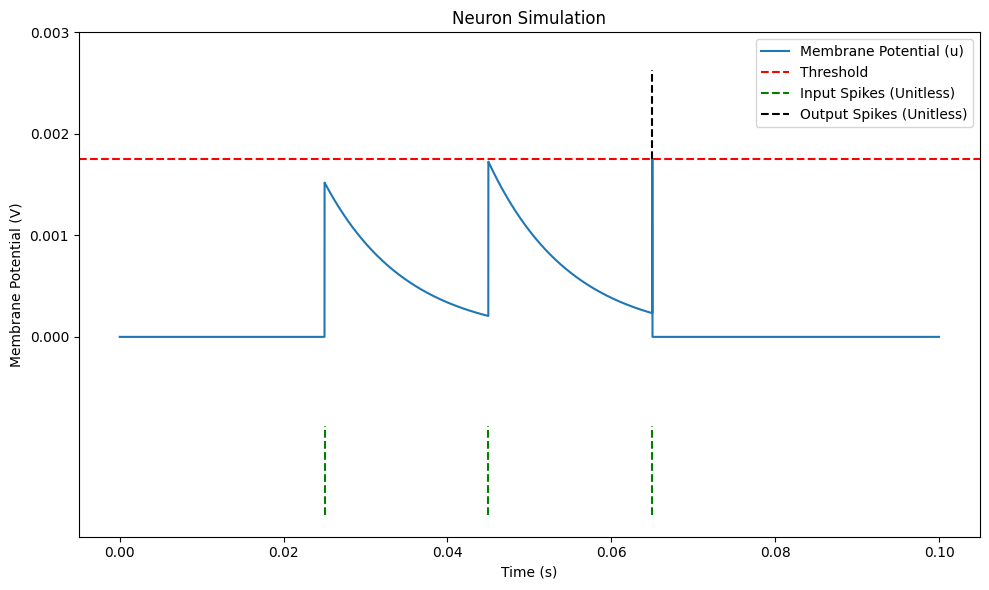

In [46]:
plt.figure(figsize=(10, 6))
plt.plot(times, U, label='Membrane Potential (u)')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
  
plt.vlines(input_spike_times, -threshold, -threshold * .50, 
           color='g', linestyle='--', label='Input Spikes (Unitless)')
plt.vlines(output_spike_times, threshold, threshold * 1.5, 
           color='black', linestyle='--', label='Output Spikes (Unitless)')
  
plt.gca().set_yticks([tick for tick in plt.gca().get_yticks() if tick >= 0])
  
plt.xlabel('Time (s)')
plt.ylabel('Membrane Potential (V)')
plt.title('Neuron Simulation')
plt.legend()
plt.tight_layout()
plt.show()